# Model comparison — hysteresis (split FTNODE vs. unsplit NODE with NO feature lift 1000 epochs, tmax=0.2)

Trains **both** models on the same hysteresis data and compares them:

* **Split (FTNODE):** `dx/dt = f(x)·(x − g(x,λ))` — architecture from
  `train-model-node-20-20-20.ipynb`.
* **Unsplit (standard NODE):** `dx/dt = NN(x, λ)` — architecture from
  `train-unsplit-20-20-20.ipynb`.

Both are trained by trajectory matching, so the data pipeline is shared. This run
uses **`n_lam = 4`, `n_traj = 4`** (coarser than the 51x51 originals), and saves to
**new** checkpoints so the existing trained models are untouched.

Contents: shared data → split training → unsplit training → learned `f`/`g` plots
(split only) → trajectory plots (both) → simulated-dynamics error metrics
(RMSE, scaled & physical) → Jacobian eigenvalues at the trajectory steady states
(both). Plots are **not** saved; models **are** saved.

In [1]:
import time
from typing import List
import numpy as np
import torch
import torch.nn as nn
import torchode
from pathlib import Path
import pickle

from scipy.integrate import solve_ivp as sp_solve_ivp
from tqdm.auto import tqdm

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed, _load_loop_wrapper
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, FeluSigmoidMLPfeaturized,
    GeluSigmoidMLP, GeluSigmoidMLPfeaturized,
)

import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family'] = 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed)

[Seed] Deterministic mode enabled (may reduce speed).


## 1. Shared data generation

Identical pipeline to both training notebooks, with `n_lam = 4, n_traj =4`.

In [2]:
def hysteresis_ode(t, x, lam):
    return lam + x - x**3

In [3]:
n_lam = 4
n_traj = 4
lams = np.linspace(-1, 1, n_lam)
xs = np.linspace(-2, 2, n_traj)

lams, xs

(array([-1.        , -0.33333333,  0.33333333,  1.        ]),
 array([-2.        , -0.66666667,  0.66666667,  2.        ]))

In [ ]:
t_max = 0.1
n_colloc = 101

Xs = []
Us = []
t = np.linspace(0, t_max, n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span=[0, t_max],
            y0=np.array(x0).reshape(-1),
            t_eval=np.linspace(0, t_max, n_colloc),
            args=(lami,),
        )
        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

  0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
# Central finite differences (kept for parity with the training notebooks).
dXs = np.zeros_like(Xs)
T = t[np.newaxis, :, np.newaxis]
X_diff = Xs[:, 2:, :] - Xs[:, :-2, :]
T_diff = T[:, 2:, :] - T[:, :-2, :]

dXs[:, 1:-1, :] = X_diff / T_diff
dXs[:, 0, :] = (Xs[:, 1, :] - Xs[:, 0, :]) / (T[:, 1, :] - T[:, 0, :])
dXs[:, -1, :] = (Xs[:, -1, :] - Xs[:, -2, :]) / (T[:, -1, :] - T[:, -2, :])

In [6]:
scaler = MinMaxScaler(feature_range=(-1, 1))
Xs_scaled = scaler.fit_transform(Xs.reshape(-1, 1).reshape(-1, 1)).reshape(-1, n_colloc, 1)
scaler.scale_

array([0.5])

In [7]:
dX_tensor = [torch.tensor(dxi, dtype=torch.float32, device=device) for dxi in dXs]
X_tensor = [torch.tensor(xi, dtype=torch.float32, device=device) for xi in Xs_scaled]
U_tensor = [torch.tensor(ui, dtype=torch.float32, device=device) for ui in Us]
T_tensor = [torch.tensor(t, dtype=torch.float32, device=device) for _ in range(len(Xs))]


class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(f"Index {idx} is out of bounds of dataset size: {len(self)}.")
        return self.dX[idx], self.X[idx], self.T[idx], self.U[idx]


dataset = GradDataset(dX=dX_tensor, X=X_tensor, T=T_tensor, U=U_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=50, shuffle=True)

## 2. Split model (FTNODE)

Architecture exactly as in `train-model-node-20-20-20-15-points.ipynb`. Saved to
`best_model-cmp-20-20-20-15-points.pth`.

In [8]:
f = FeluSigmoidMLP(
    dims=[1, 20, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None,
)

g = GeluSigmoidMLP(
    dims=[2, 20, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    init_type=None,
)

model_split = FTNODE(f, g).to(device)

In [9]:
n_epochs = 1000
_precision = 5
print_every = 10
solve_method = 'tsit5'

loss_criteria = nn.MSELoss()
opt = torch.optim.Adam(list(f.parameters()) + list(g.parameters()), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10)

best_loss = float('inf')
best_split_path = f"best_model-cmp-nofeat-20-20-20-n_lam-{n_lam}-n_traj-{n_traj}-epochs-{n_epochs}-tmax-{t_max}.pth"

model_split.train()
losses_split = []
lrs_split = []

for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0
    for batch_idx, (dXi, Xi, ti, ui) in enumerate(dataloader):
        x0i = Xi[:, 0, :]
        u_func = lambda t: ui
        func = lambda t, x: model_split(t, x, u_func)   # FTNODE: (t, x, u_func)

        opt.zero_grad()
        sol = torchode.solve_ivp(f=func, y0=x0i, t_eval=ti.squeeze(), method=solve_method)
        Xi_pred = sol.ys
        loss = loss_criteria(Xi, Xi_pred)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(dataloader)
    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch_split = epoch
        torch.save(model_split.state_dict(), best_split_path)

    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch}: Loss = {epoch_loss:.{_precision}e}, "
              f"Best = {best_loss:.{_precision}e}, time = {epoch_time:.{_precision}e}, "
              f"lr = {cur_lr:.{_precision}e}")

    losses_split.append(epoch_loss)
    lrs_split.append(cur_lr)

print(f"Split training complete. Best loss: {best_loss:.6e} @ epoch {best_epoch_split}")
model_split.load_state_dict(torch.load(best_split_path))
model_split.eval()

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0: Loss = 9.75221e-03, Best = 9.75221e-03, time = 1.80303e-01, lr = 1.00000e-02
Epoch 1: Loss = 8.20369e-03, Best = 8.20369e-03, time = 4.36532e-02, lr = 1.00000e-02
Epoch 2: Loss = 6.89702e-03, Best = 6.89702e-03, time = 4.95028e-02, lr = 1.00000e-02
Epoch 3: Loss = 5.75352e-03, Best = 5.75352e-03, time = 4.30381e-02, lr = 1.00000e-02
Epoch 4: Loss = 4.76473e-03, Best = 4.76473e-03, time = 4.13828e-02, lr = 1.00000e-02
Epoch 5: Loss = 4.02410e-03, Best = 4.02410e-03, time = 3.53620e-02, lr = 1.00000e-02
Epoch 10: Loss = 4.20045e-03, Best = 3.70122e-03, time = 3.72648e-02, lr = 1.00000e-02
Epoch 20: Loss = 3.58043e-03, Best = 3.52336e-03, time = 2.94640e-02, lr = 1.00000e-02
Epoch 30: Loss = 3.16561e-03, Best = 3.16561e-03, time = 3.93822e-02, lr = 1.00000e-02
Epoch 40: Loss = 1.96921e-03, Best = 1.96921e-03, time = 3.64721e-02, lr = 1.00000e-02
Epoch 50: Loss = 1.06351e-03, Best = 1.06351e-03, time = 4.58434e-02, lr = 1.00000e-02
Epoch 60: Loss = 1.07110e-03, Best = 1.04150e-03,

FTNODE(
  (f): FeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=1, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=1, bias=True)
      )
    )
  )
  (g): GeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=2, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=1, bias=True)
      )
    )
  )
)

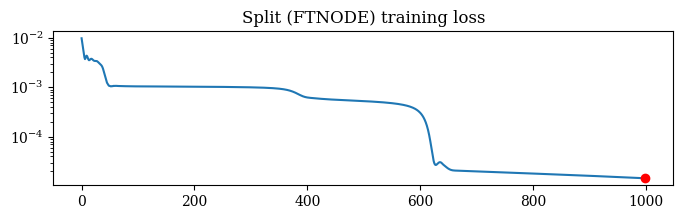

In [10]:
plt.figure(figsize=(8, 2))
plt.plot(losses_split)
plt.yscale('log')
plt.scatter(best_epoch_split, losses_split[best_epoch_split], marker='o', c='red', zorder=2)
plt.title("Split (FTNODE) training loss")
plt.show()

## 3. Unsplit model (standard NODE)

Architecture exactly as in `train-unsplit-20-20-20-15-points.ipynb`. Saved to
`best_model-unsplit-nofeat-cmp-20-20-20-15-points.pth`.

In [11]:
model_unsplit = GeluSigmoidMLP(
    dims=[2, 20, 20, 20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=2,
    init_type=None,
).to(device)

In [12]:
n_epochs = 1000
_precision = 5
print_every = 10
solve_method = 'tsit5'

loss_criteria = nn.MSELoss()
opt = torch.optim.Adam(model_unsplit.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10)

best_loss = float('inf')
best_unsplit_path = f"best_model-unsplit-nofeat-cmp-20-20-20-n_lam-{n_lam}-n_traj-{n_traj}-epochs-{n_epochs}-tmax-{t_max}.pth"

model_unsplit.train()
losses_unsplit = []
lrs_unsplit = []

for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0
    for batch_idx, (dXi, Xi, ti, ui) in enumerate(dataloader):
        x0i = Xi[:, 0, :]
        u_func = lambda t: ui
        func = lambda t, x: model_unsplit(x, u_func(t))   # standard NODE: (x, u)

        opt.zero_grad()
        sol = torchode.solve_ivp(f=func, y0=x0i, t_eval=ti.squeeze(), method=solve_method)
        Xi_pred = sol.ys
        loss = loss_criteria(Xi, Xi_pred)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(dataloader)
    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch_unsplit = epoch
        torch.save(model_unsplit.state_dict(), best_unsplit_path)

    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch}: Loss = {epoch_loss:.{_precision}e}, "
              f"Best = {best_loss:.{_precision}e}, time = {epoch_time:.{_precision}e}, "
              f"lr = {cur_lr:.{_precision}e}")

    losses_unsplit.append(epoch_loss)
    lrs_unsplit.append(cur_lr)

print(f"Unsplit training complete. Best loss: {best_loss:.6e} @ epoch {best_epoch_unsplit}")
model_unsplit.load_state_dict(torch.load(best_unsplit_path))
model_unsplit.eval()

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0: Loss = 4.51933e-02, Best = 4.51933e-02, time = 3.86221e-02, lr = 1.00000e-02
Epoch 1: Loss = 4.14080e-02, Best = 4.14080e-02, time = 2.14450e-02, lr = 1.00000e-02
Epoch 2: Loss = 3.79342e-02, Best = 3.79342e-02, time = 2.23570e-02, lr = 1.00000e-02
Epoch 3: Loss = 3.45546e-02, Best = 3.45546e-02, time = 2.67704e-02, lr = 1.00000e-02
Epoch 4: Loss = 3.11143e-02, Best = 3.11143e-02, time = 2.47200e-02, lr = 1.00000e-02
Epoch 5: Loss = 2.75418e-02, Best = 2.75418e-02, time = 4.04489e-02, lr = 1.00000e-02
Epoch 10: Loss = 1.35345e-02, Best = 1.35345e-02, time = 2.19002e-02, lr = 1.00000e-02
Epoch 20: Loss = 5.29095e-03, Best = 4.26282e-03, time = 2.15399e-02, lr = 1.00000e-02
Epoch 30: Loss = 4.22741e-03, Best = 4.22741e-03, time = 2.53482e-02, lr = 1.00000e-02
Epoch 40: Loss = 4.30086e-03, Best = 4.22741e-03, time = 2.12679e-02, lr = 1.00000e-02
Epoch 50: Loss = 4.02824e-03, Best = 4.02712e-03, time = 2.16198e-02, lr = 5.00000e-03
Epoch 60: Loss = 4.00543e-03, Best = 4.00543e-03,

GeluSigmoidMLP(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

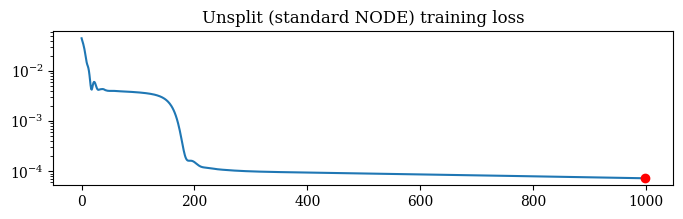

In [13]:
plt.figure(figsize=(8, 2))
plt.plot(losses_unsplit)
plt.yscale('log')
plt.scatter(best_epoch_unsplit, losses_unsplit[best_epoch_unsplit], marker='o', c='red', zorder=2)
plt.title("Unsplit (standard NODE) training loss")
plt.show()

## 4. Learned `f` and `g` (split model only)

These structural plots only exist for the split architecture — the unsplit model has
no `f`/`g` decomposition.

In [14]:
f = model_split.f
g = model_split.g
f.eval()
g.eval()


def f_true(x):
    return -x**2

def g_true(x, lam):
    return (1 / x) * (lam / x + 1)

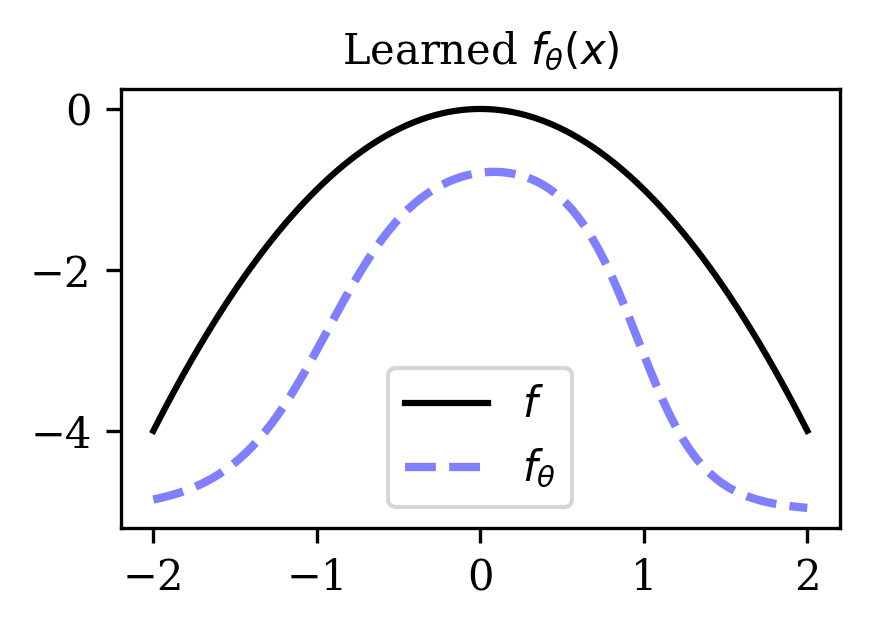

In [15]:
# Learned f_theta(x) vs analytic f.
plt.figure(figsize=(3, 2.), dpi=300)
x_lin = np.linspace(-2, 2, 101)
lam_lin = np.linspace(-1, 1, 101)
x_lin_scaled = scaler.transform(x_lin.reshape(-1, 1))
x_lin_scaled_torch = torch.tensor(x_lin_scaled, dtype=torch.float32)
with torch.no_grad():
    f_node = f(x_lin_scaled_torch).reshape(-1)

plt.plot(x_lin, f_true(x_lin), label=r"$f$", c='black')
plt.plot(x_lin, np.array(f_node), label=r"$f_\theta$", c='blue', alpha=0.5, linestyle="--", lw=2)
plt.tight_layout()
plt.legend(fontsize=10)
plt.title(r"Learned $f_\theta(x)$", size=10)
plt.show()

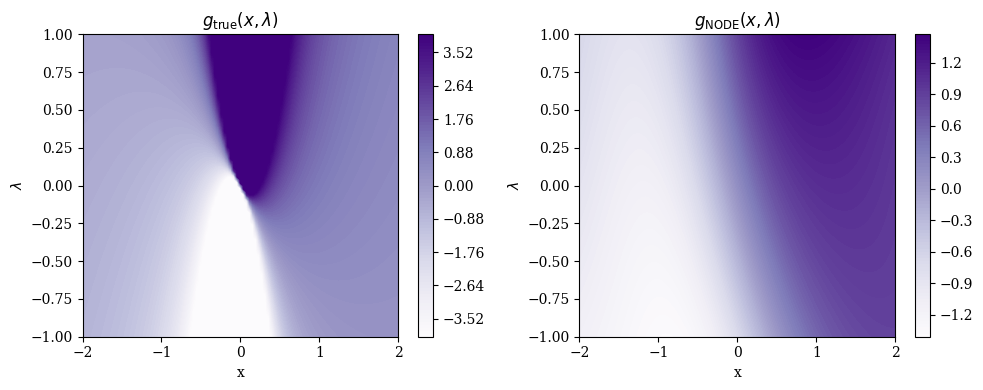

In [16]:
# g contour: analytic vs learned.
X, L = np.meshgrid(x_lin, lam_lin)
with np.errstate(divide='ignore', invalid='ignore'):
    Z = g_true(X, L)
Z = np.nan_to_num(Z, nan=0, posinf=4, neginf=-4)
Z_clipped = np.clip(Z, -4, 4)

X_torch_scaled = torch.tensor(scaler.transform(X.reshape(-1, 1)), dtype=torch.float32)
L_torch = torch.tensor(L.reshape(-1, 1), dtype=torch.float32)
with torch.no_grad():
    Z_node = g(X_torch_scaled, L_torch)
Z_node_unscaled = scaler.inverse_transform(Z_node).reshape(X.shape)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ax = axs[0]
contour = ax.contourf(X, L, Z_clipped, levels=100, cmap='Purples')
plt.colorbar(contour, ax=ax)
ax.set_xlabel('x'); ax.set_ylabel(r'$\lambda$'); ax.set_title(r'$g_{\text{true}}(x, \lambda)$')
ax = axs[1]
contour = ax.contourf(X, L, Z_node_unscaled, levels=100, cmap='Purples')
plt.colorbar(contour, ax=ax)
ax.set_xlabel('x'); ax.set_ylabel(r'$\lambda$'); ax.set_title(r'$g_{\text{NODE}}(x, \lambda)$')
plt.tight_layout()
plt.show()

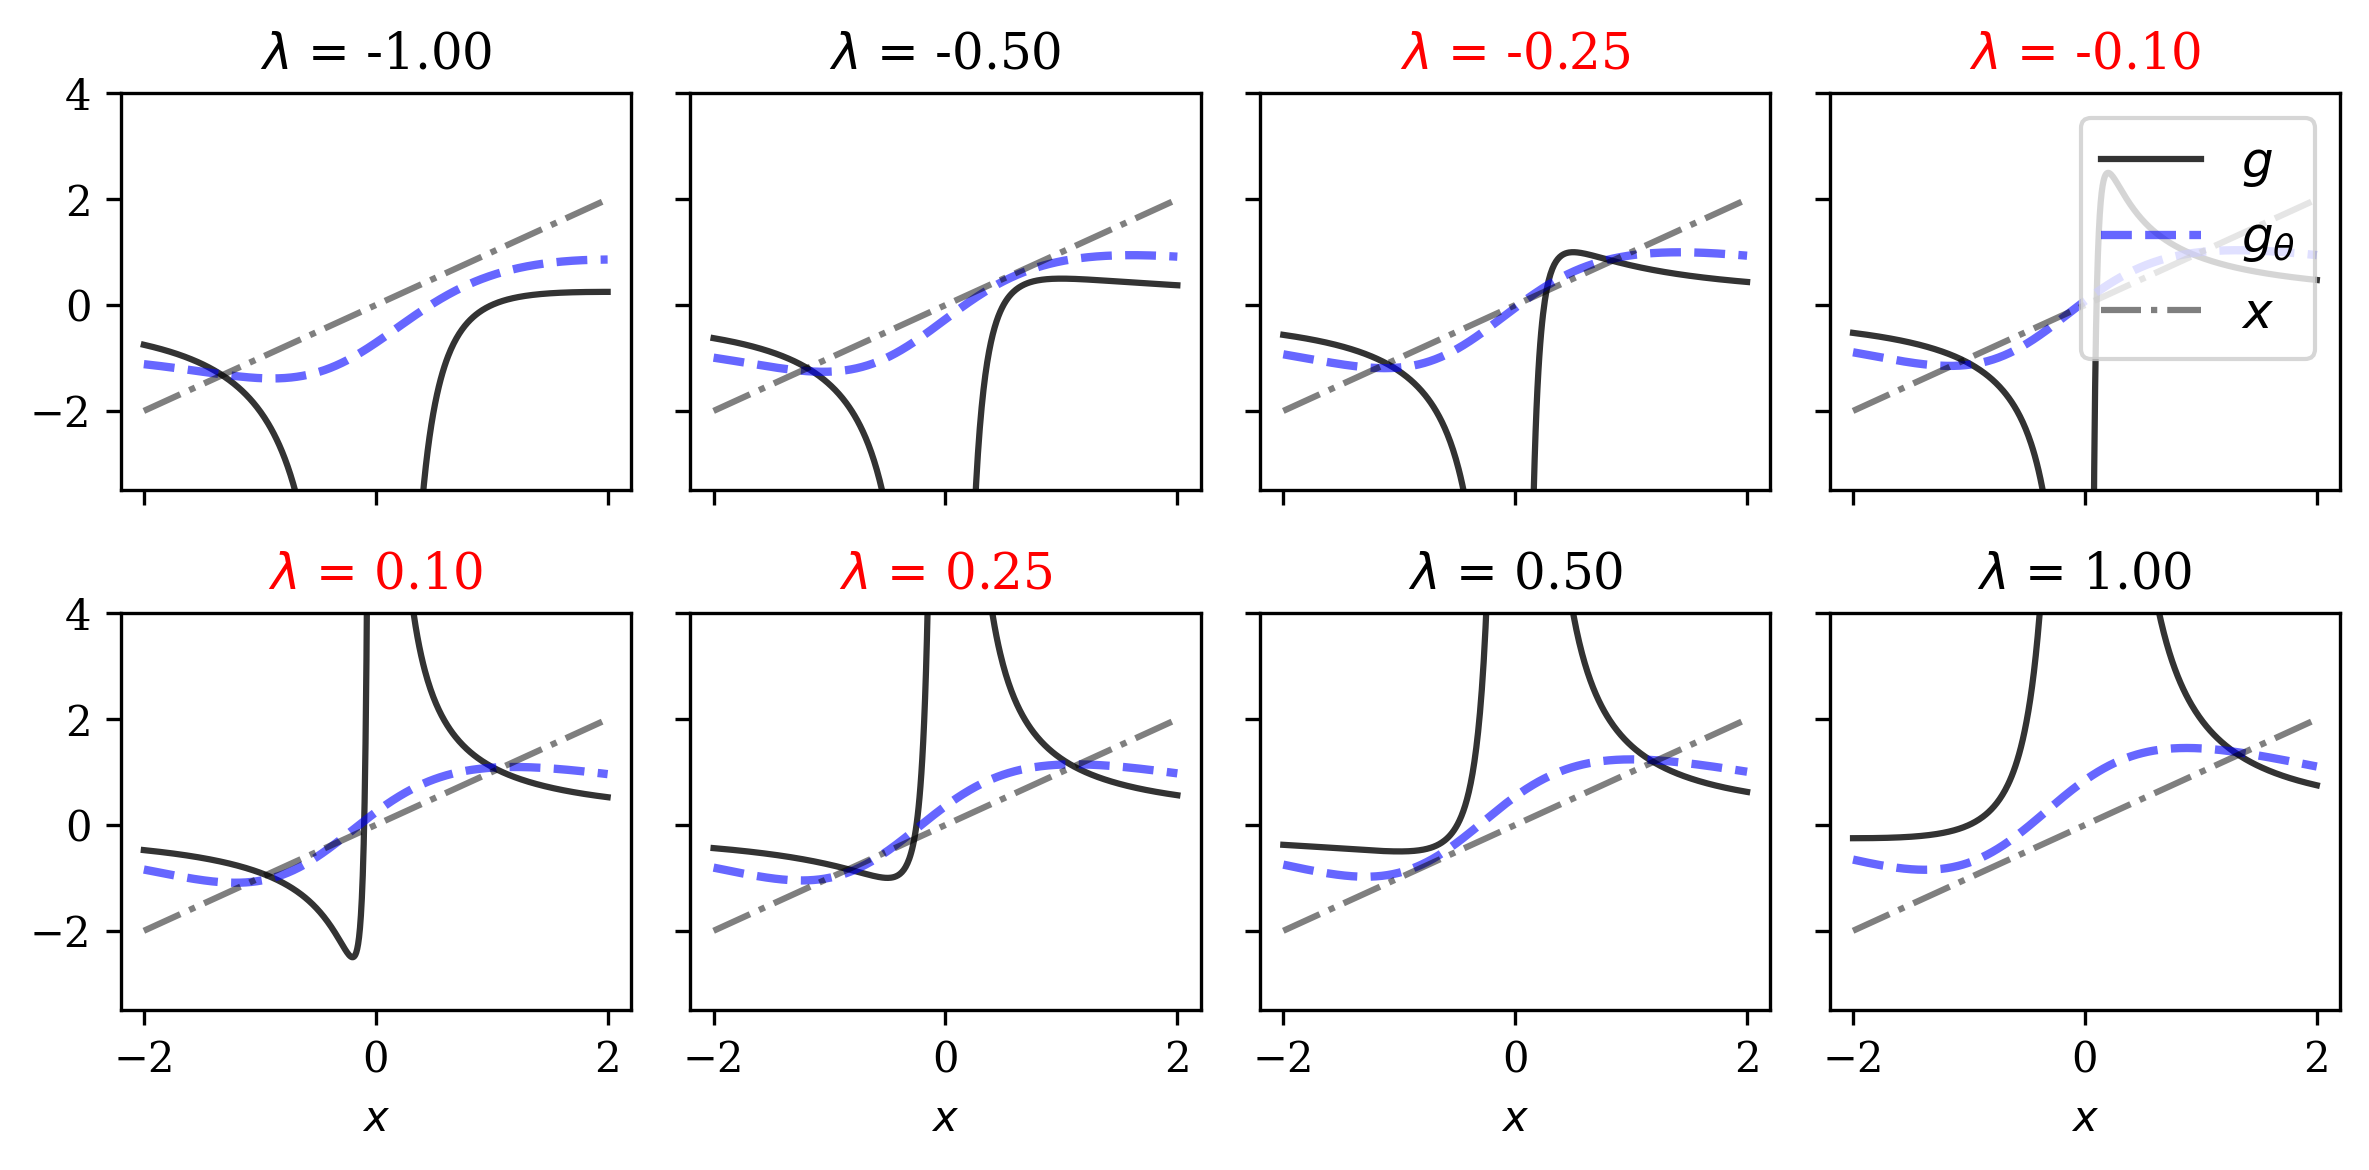

In [17]:
# g slices across lambda: analytic vs learned, with the x=g fixed-point line.
x_lin = np.linspace(-2, 2, 501)
x_tensor_scaled = torch.tensor(scaler.transform(x_lin.reshape(-1, 1)), dtype=torch.float32)
lams_g = [-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1]

fig, axs = plt.subplots(2, 4, figsize=(8, 4), sharey=True, sharex=True, dpi=300)
axs = axs.flatten()
for idx, ax in enumerate(axs):
    lami = lams_g[idx]
    lami_tensor = torch.tensor(lami, dtype=torch.float32).expand(x_tensor_scaled.shape)
    with torch.no_grad():
        g_pred = scaler.inverse_transform(g(x_tensor_scaled, lami_tensor)).reshape(-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        g_out = g_true(x_lin, lami)
    g_clipped = np.clip(g_out, -10, 10)

    label1 = label2 = label3 = None
    if idx == 3:
        label1, label2, label3 = r"$g$", r"$g_\theta$", r"$x$"
    ax.plot(x_lin, g_clipped, c='black', alpha=0.8, label=label1)
    ax.plot(x_lin, g_pred, c='blue', linestyle='--', lw=2, alpha=0.6, label=label2)
    ax.plot(x_lin, x_lin, c='black', alpha=0.5, linestyle='-.', label=label3)
    ax.set_ylim(-3.5, 4)
    color = 'red' if -np.sqrt(4 / 27) < lami < np.sqrt(4 / 27) else 'black'
    ax.set_title(rf"$\lambda$ = {lami:.2f}", c=color)
    if idx == 3:
        ax.legend(fontsize=12, loc='upper right')
    if idx >= 4:
        ax.set_xlabel(r"$x$")
plt.tight_layout()
plt.show()

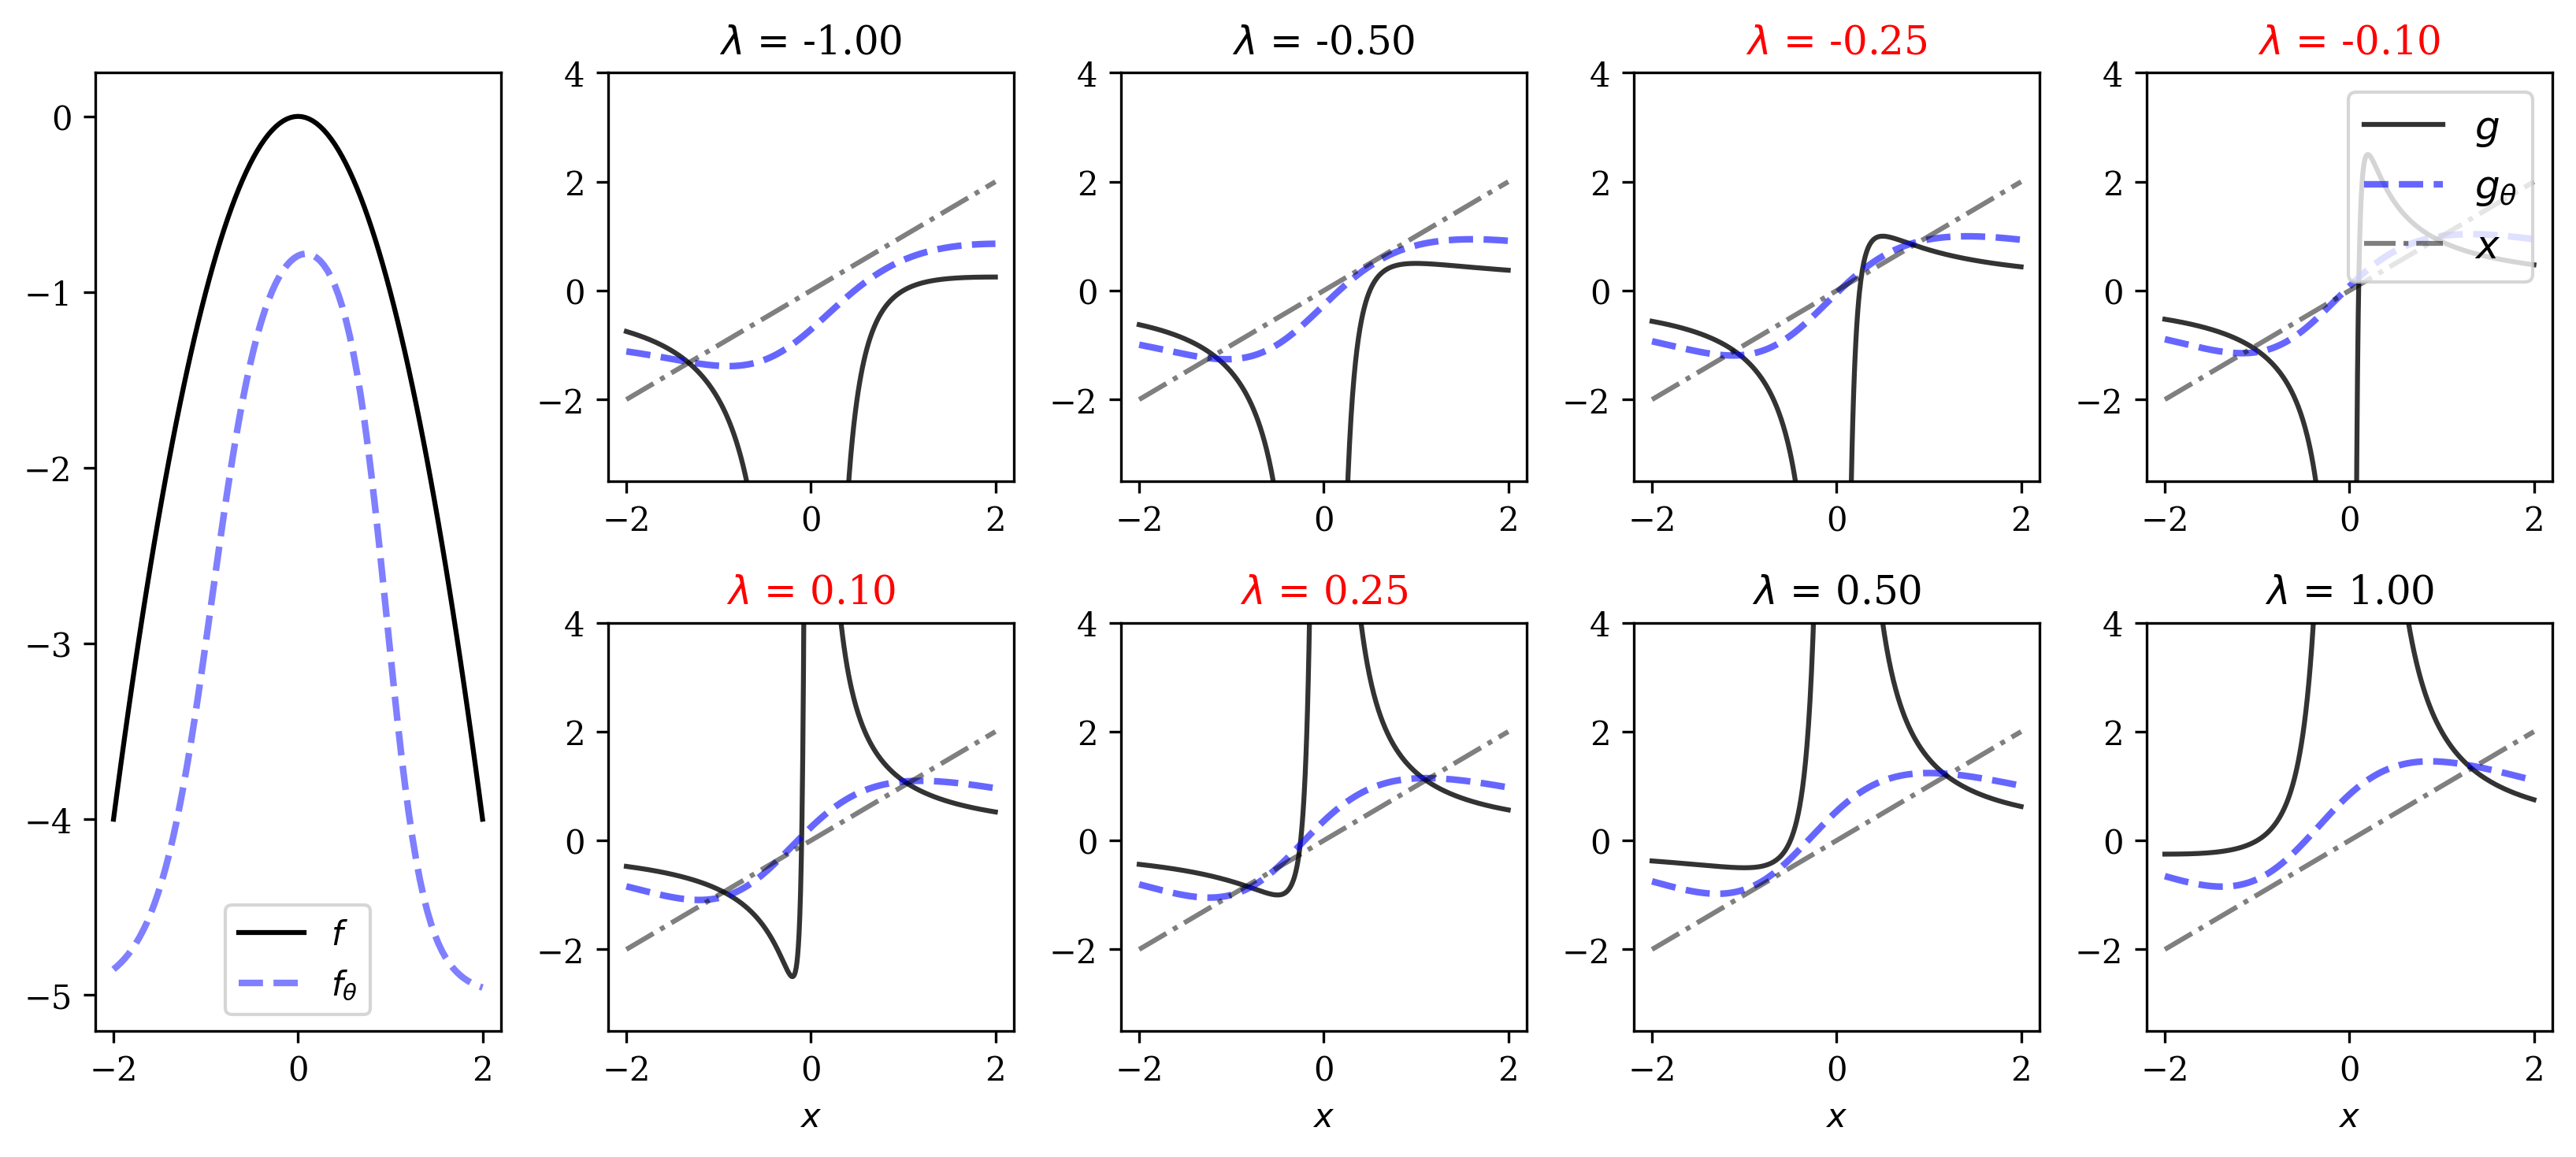

In [18]:
# Combined f (left) + g grid (right).
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(11, 5), dpi=300)
gs = GridSpec(2, 5, figure=fig)
ax_f = fig.add_subplot(gs[:, 0])
axs_g = [fig.add_subplot(gs[i, j + 1]) for i in range(2) for j in range(4)]
axs_g = np.array(axs_g).reshape(2, 4)

x_lin = np.linspace(-2, 2, 101)
x_lin_scaled = scaler.transform(x_lin.reshape(-1, 1))
x_lin_scaled_torch = torch.tensor(x_lin_scaled, dtype=torch.float32)
with torch.no_grad():
    f_node = f(x_lin_scaled_torch).reshape(-1)
ax_f.plot(x_lin, f_true(x_lin), label=r"$f$", c='black')
ax_f.plot(x_lin, np.array(f_node), label=r"$f_\theta$", c='blue', alpha=0.5, linestyle="--", lw=2)
ax_f.legend(fontsize=10)

x_lin = np.linspace(-2, 2, 501)
x_tensor_scaled = torch.tensor(scaler.transform(x_lin.reshape(-1, 1)), dtype=torch.float32)
lams_g = [-1, -0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1]
axs = axs_g.flatten()
for idx, ax in enumerate(axs):
    lami = lams_g[idx]
    lami_tensor = torch.tensor(lami, dtype=torch.float32).expand(x_tensor_scaled.shape)
    with torch.no_grad():
        g_pred = scaler.inverse_transform(g(x_tensor_scaled, lami_tensor)).reshape(-1)
    with np.errstate(divide='ignore', invalid='ignore'):
        g_out = g_true(x_lin, lami)
    g_clipped = np.clip(g_out, -10, 10)
    label1 = label2 = label3 = None
    if idx == 3:
        label1, label2, label3 = r"$g$", r"$g_\theta$", r"$x$"
    ax.plot(x_lin, g_clipped, c='black', alpha=0.8, label=label1)
    ax.plot(x_lin, g_pred, c='blue', linestyle='--', lw=2, alpha=0.6, label=label2)
    ax.plot(x_lin, x_lin, c='black', alpha=0.5, linestyle='-.', label=label3)
    ax.set_ylim(-3.5, 4)
    color = 'red' if -np.sqrt(4 / 27) < lami < np.sqrt(4 / 27) else 'black'
    ax.set_title(rf"$\lambda$ = {lami:.2f}", c=color)
    if idx == 3:
        ax.legend(fontsize=12, loc='upper right')
    if idx >= 4:
        ax.set_xlabel(r"$x$")
plt.tight_layout()
plt.show()

## 5. Trajectory plots (both models)

Each subplot is one control `λ`. A dedicated set of **11 initial conditions
`x0 = np.linspace(-1, 1, 11)`** (independent of the training data) is integrated to
`t = 100` and overlaid on the true trajectories. `split=True` uses the FTNODE closure
`model(t, x, u_func)`; `split=False` uses the NODE closure `model(x, u)`.

In [19]:
n_ic = 31
n_control = 31

In [20]:
# Dedicated plotting initial conditions in [-2, 2] (decoupled from the training data).
x0_plot = np.linspace(-2, 2, n_ic)
x0_plot_scaled = scaler.transform(x0_plot.reshape(-1, 1))
lams_plot = np.linspace(-1, 1, n_control)   # one control per subplot


def plot_ax(ax, case, model_obj, split):
    lami = lams_plot[case]
    n_colloc_p = 501
    t_max_p = 100
    ti = np.linspace(0, t_max_p, n_colloc_p)
    Ti = torch.tensor(ti, dtype=torch.float32)

    y0 = torch.tensor(x0_plot_scaled, dtype=torch.float32)           # [n_ic, 1]
    lam_t = torch.full((len(x0_plot), 1), float(lami), dtype=torch.float32)
    with torch.no_grad():
        if split:
            func = lambda t, x: model_obj(t, x, lambda tt: lam_t)
        else:
            func = lambda t, x: model_obj(x, lam_t)
        sol_model = torchode.solve_ivp(f=func, y0=y0, t_eval=Ti.squeeze(), method='tsit5')

    sol = sp_solve_ivp(
        hysteresis_ode,
        t_span=[0, ti[-1]],
        y0=x0_plot,
        t_eval=np.linspace(0, ti[-1], n_colloc_p),
        args=(lami,),
    )
    y_true = scaler.transform(sol.y.reshape(-1, 1)).reshape(len(x0_plot), n_colloc_p).T
    y_pred = sol_model.ys.squeeze(dim=-1).numpy().T

    for j in range(len(x0_plot)):
        label1 = label2 = None
        if j == 0:
            label1, label2 = "True", "Model"
        ax.plot(ti, y_true[:, j], c='black', zorder=1, label=label1)
        ax.plot(ti, y_pred[:, j], c='blue', alpha=0.4, lw=3, zorder=1, label=label2, linestyle='--')

    ax.axvline(t_max, color='red', linestyle='--', alpha=0.8, label='train horizon')
    ax.set_ylim(-1.2, 1.2)
    color = 'red' if -np.sqrt(4 / 27) < lami < np.sqrt(4 / 27) else 'black'
    ax.set_title(rf"$\lambda$ = {lami:.2f} ", c=color)
    ax.set_xscale('symlog', linthresh=0.5)
    ax.legend()


def trajectory_grid(model_obj, split, suptitle):
    n_cols = 5
    n_rows = int(np.ceil(n_control / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows),
                            dpi=200, sharex=True, sharey=True)
    axs = axs.flatten()
    for idx, ax in enumerate(tqdm(axs)):
        if idx > n_control - 1:
            break
        plot_ax(ax, case=idx, model_obj=model_obj, split=split)
    for idx in range(n_control, n_rows * n_cols):
        fig.delaxes(axs[idx])
    plt.tight_layout()
    plt.suptitle(suptitle, y=1.01, fontsize=20)
    plt.show()

  0%|          | 0/35 [00:00<?, ?it/s]

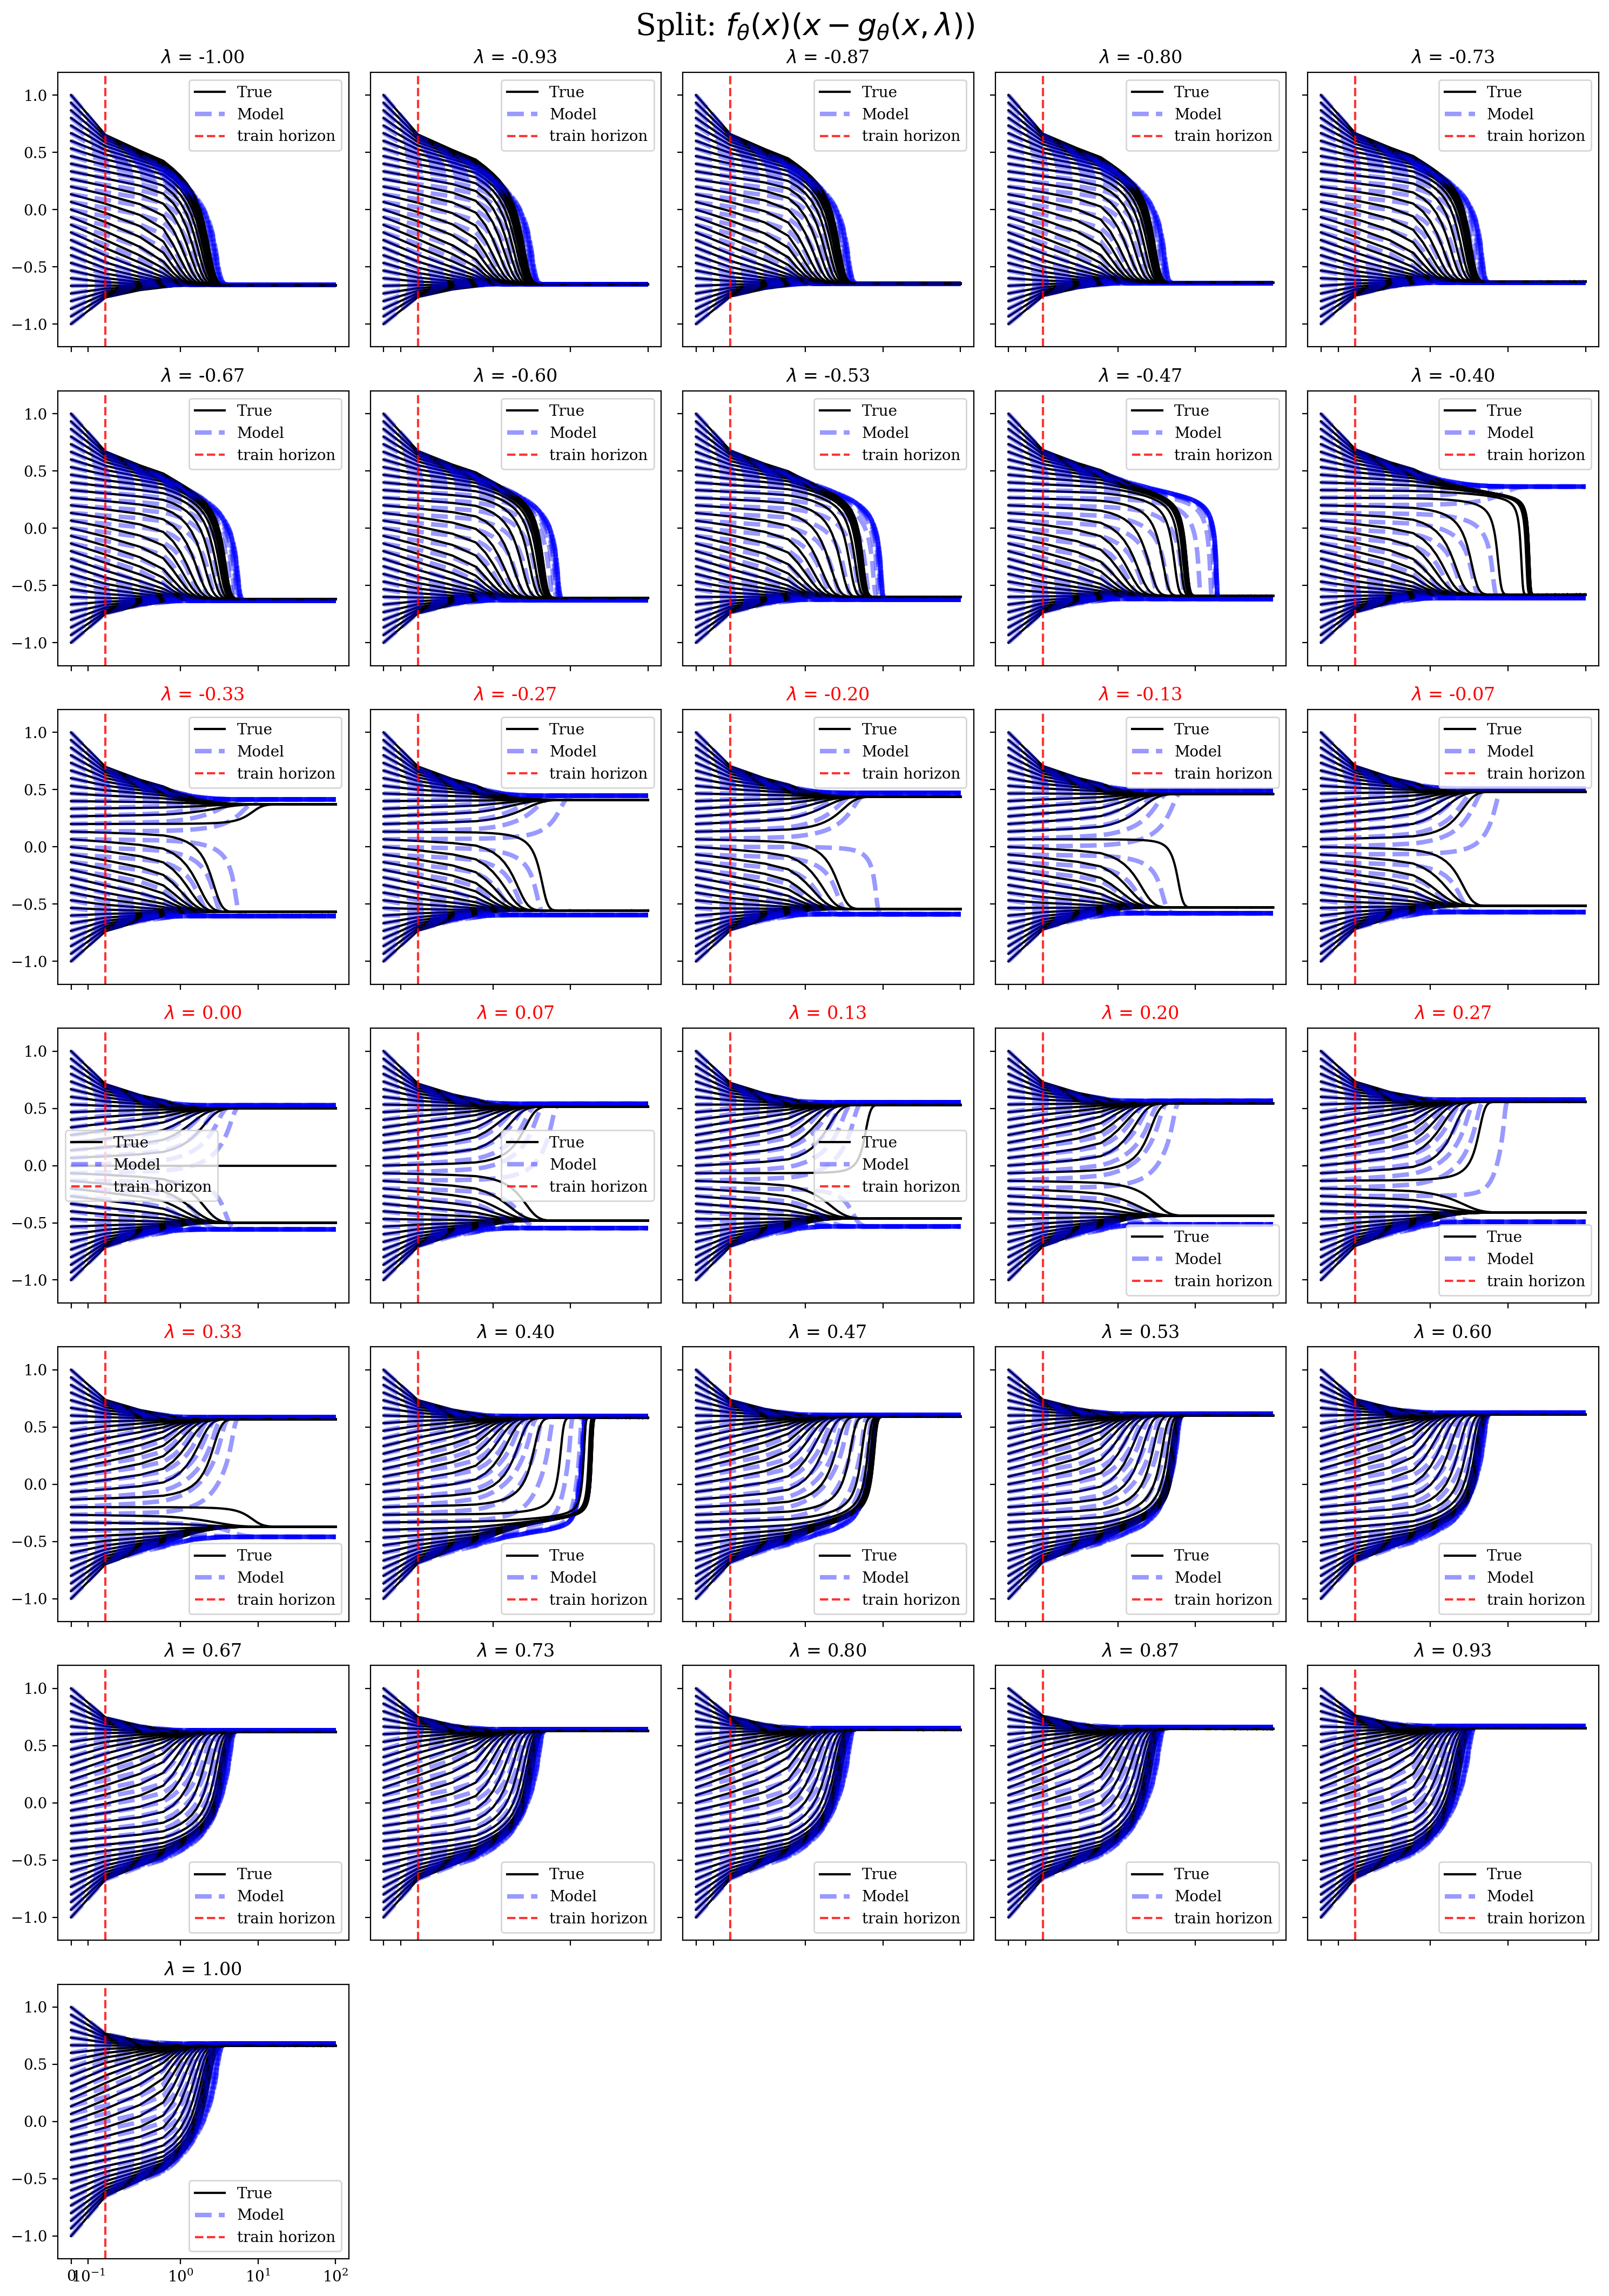

In [21]:
# Split model trajectories.
trajectory_grid(model_split, split=True, suptitle=r"Split: $f_{\theta}(x)(x-g_{\theta}(x,\lambda))$")

  0%|          | 0/35 [00:00<?, ?it/s]

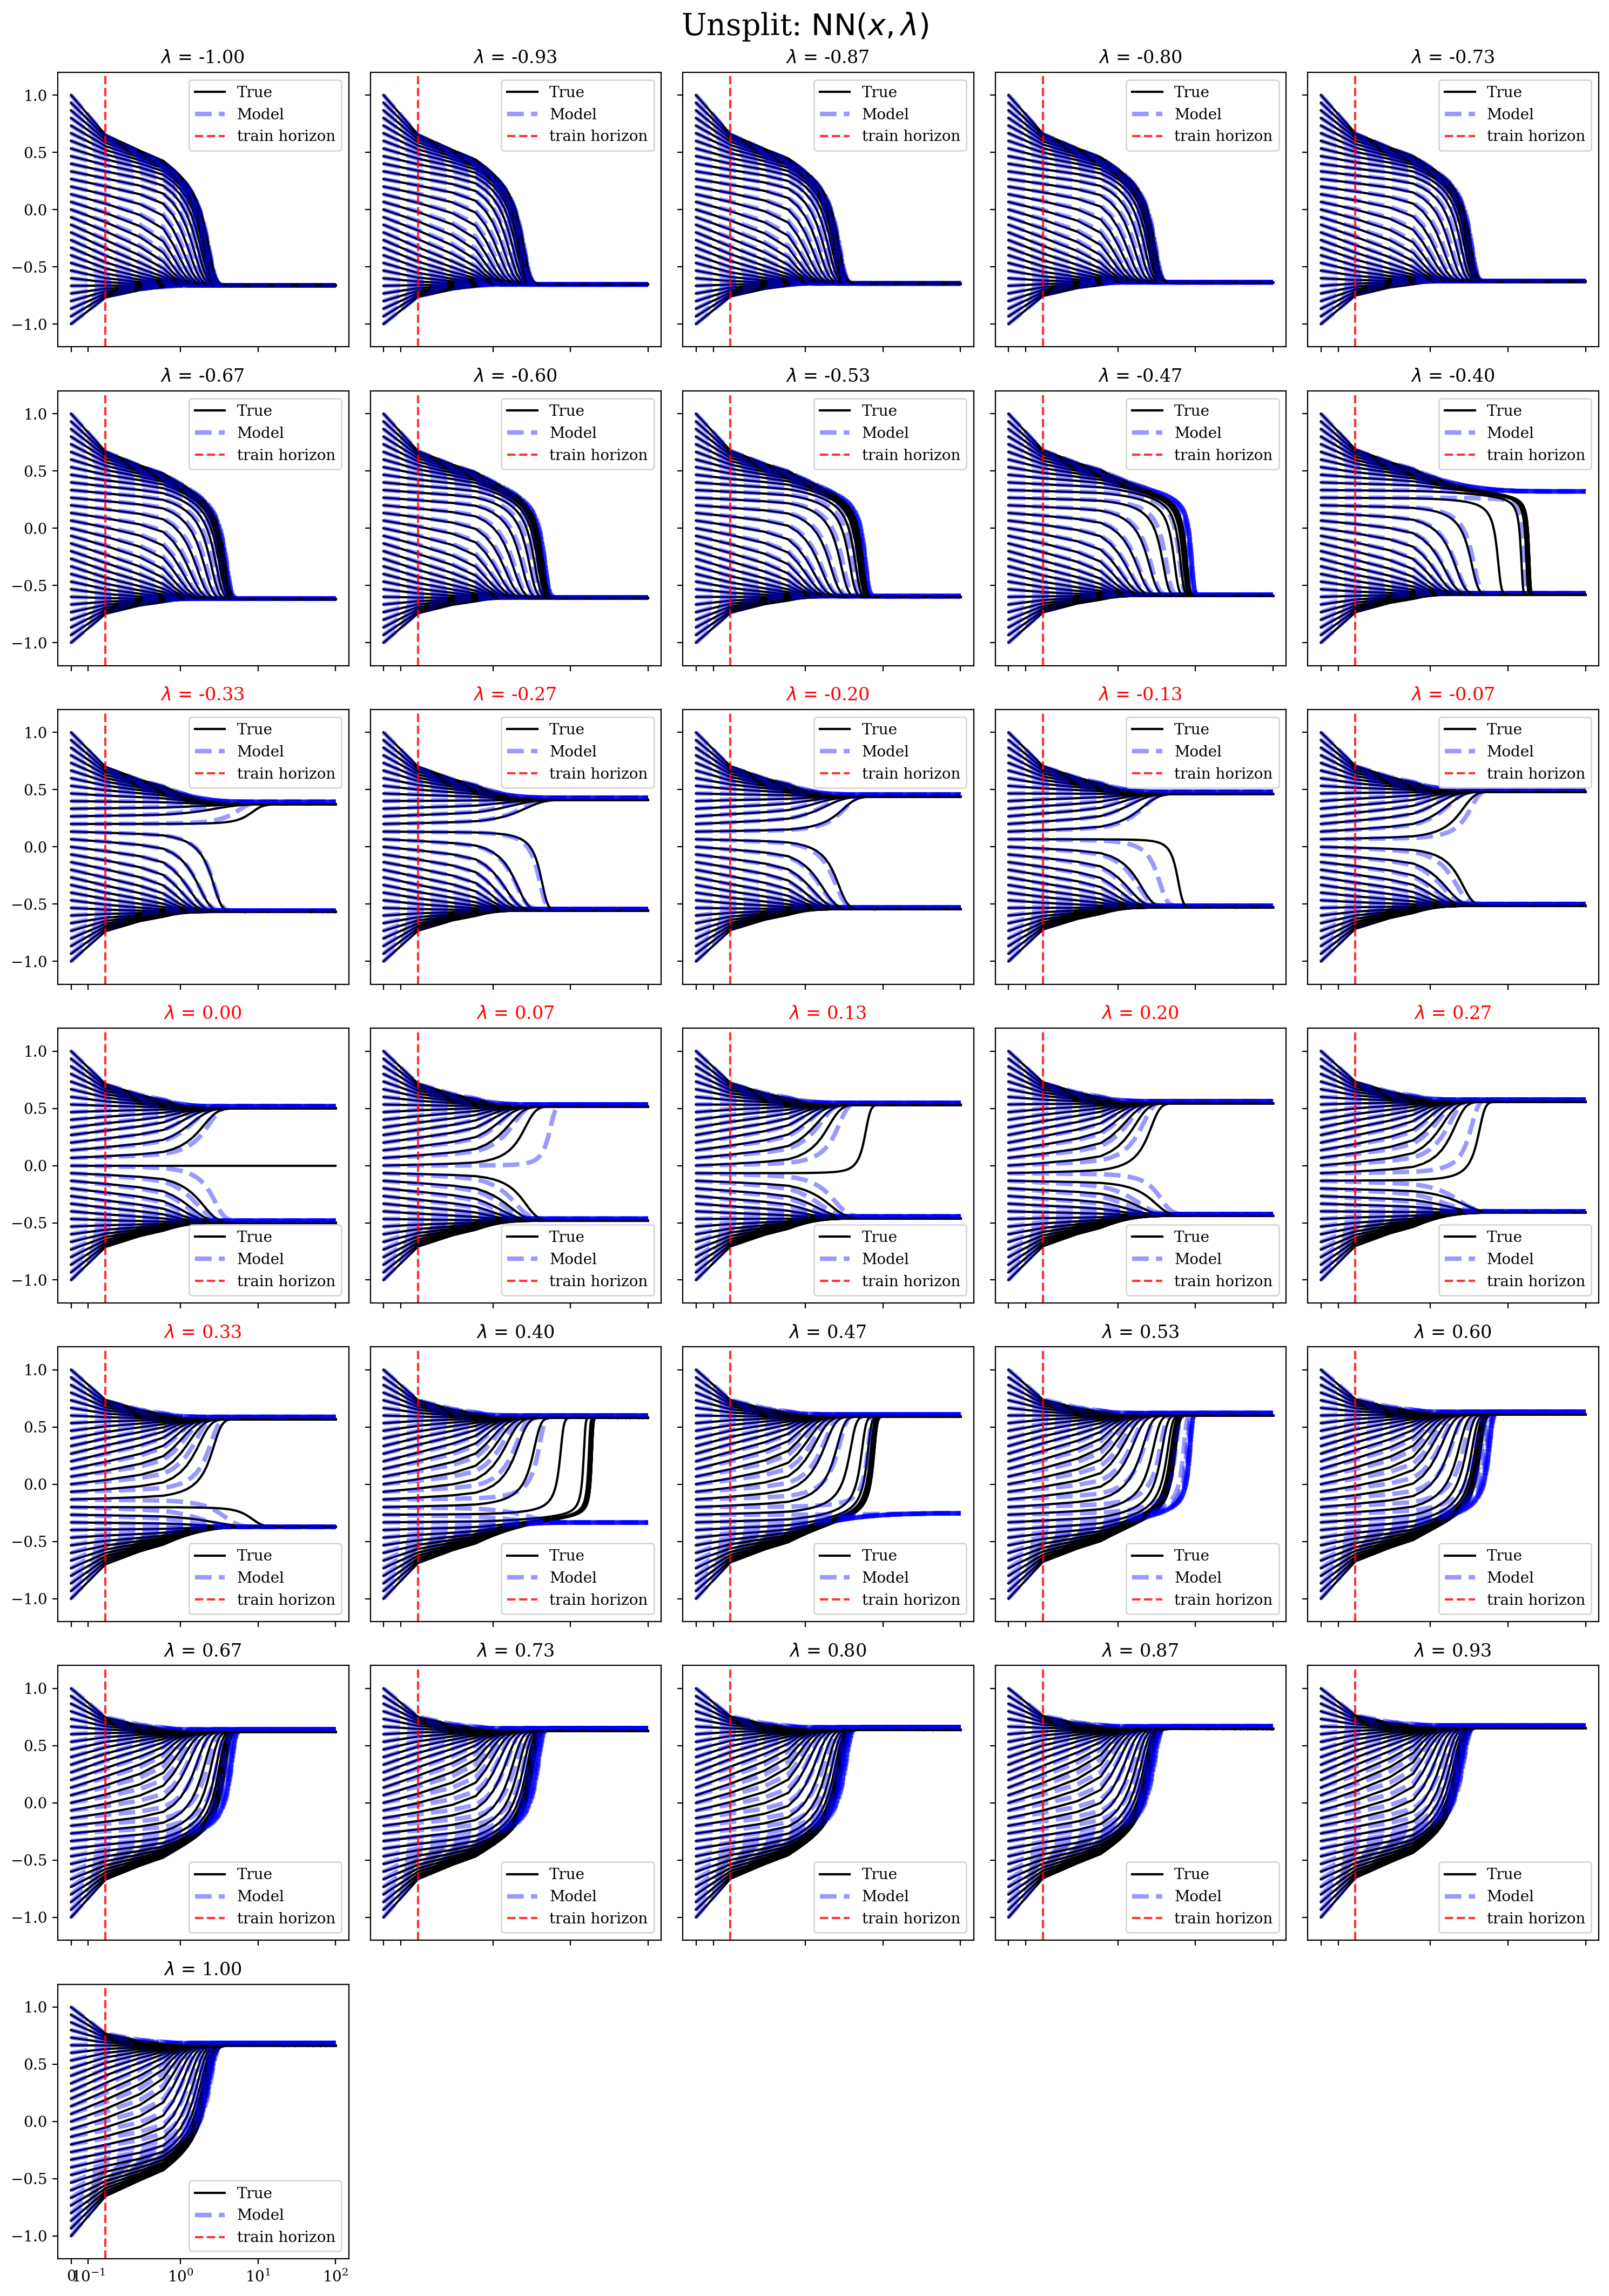

In [22]:
# Unsplit model trajectories.
trajectory_grid(model_unsplit, split=False, suptitle=r"Unsplit: $\mathrm{NN}(x,\lambda)$")

## 6. Simulated-dynamics error metrics

Evaluation is done on a **dense grid** dictated by `n_control` and `n_ic` (the same grid
used for the trajectory plots): `n_control` controls `λ ∈ [-1, 1]` × `n_ic` initial
conditions `x0 ∈ [-2, 2]`. For each `(x0, λ)` case the **true** trajectory is generated
fresh with `solve_ivp` (no longer reusing the scarce training set `Xs_scaled`), and each
model is integrated over the same time grid. Both are settled to a **long horizon
`t = 100`** (matching the trajectory plots / Jacobian section). RMSE is reported in
**scaled** coordinates (the training-loss space) and **physical** coordinates, both
per-`λ` and overall. The **endpoint (`t = 100`) absolute error** of every simulated
trajectory is additionally reported and plotted across all control cases.

In [23]:
# Dense evaluation grid dictated by n_control and n_ic (same ranges as the trajectory
# plots), independent of the scarce training points in `Xs_scaled`.
lams_data = np.linspace(-1, 1, n_control)
xs_data = np.linspace(-2, 2, n_ic)
xs_scaled_tensor_data = torch.tensor(scaler.transform(xs_data.reshape(-1, 1)), dtype=torch.float32)


def to_phys(arr_scaled):
    shp = arr_scaled.shape
    return scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).reshape(shp)


def true_all(t_max_sim, n_colloc_sim):
    """True trajectories for every (x0, lambda) on the dense grid via solve_ivp.

    Returns (physical, scaled) states, each [n_control, n_ic, n_colloc, 1].
    """
    t_eval = np.linspace(0, t_max_sim, n_colloc_sim)
    ys_phys = np.empty((n_control, n_ic, n_colloc_sim, 1))
    for i, lami in enumerate(tqdm(lams_data)):
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span=[0, t_max_sim],
            y0=xs_data,                 # vectorized over the n_ic initial conditions
            t_eval=t_eval,
            args=(lami,),
        )
        ys_phys[i] = sol.y[..., np.newaxis]   # sol.y: [n_ic, n_colloc]
    ys_scaled = scaler.transform(ys_phys.reshape(-1, 1)).reshape(ys_phys.shape)
    return ys_phys, ys_scaled


def simulate_all(model_obj, split, t_max_sim, n_colloc_sim):
    """Integrate every (x0, lambda) case. Returns scaled states [n_control, n_ic, n_colloc, 1]."""
    t_eval = torch.tensor(np.linspace(0, t_max_sim, n_colloc_sim), dtype=torch.float32)
    ys_all = []
    for lami in tqdm(lams_data):
        y0 = xs_scaled_tensor_data
        lam_t = torch.full((n_ic, 1), float(lami), dtype=torch.float32)
        if split:
            func = lambda t, x: model_obj(t, x, lambda tt: lam_t)
        else:
            func = lambda t, x: model_obj(x, lam_t)
        with torch.no_grad():
            sol = torchode.solve_ivp(f=func, y0=y0, t_eval=t_eval, method='tsit5')
        ys_all.append(sol.ys.numpy())
    return np.array(ys_all)

In [24]:
# Error on the long settle horizon (t=100), evaluated on the dense (n_control x n_ic) grid.
t_max_eval = 100
n_colloc_eval = 501

# True reference trajectories generated fresh on the dense grid (not the training set).
Xs_phys_grid, Xs_scaled_grid = true_all(t_max_eval, n_colloc_eval)   # [n_control, n_ic, n_colloc_eval, 1]

ys_split = simulate_all(model_split, split=True, t_max_sim=t_max_eval, n_colloc_sim=n_colloc_eval)
ys_unsplit = simulate_all(model_unsplit, split=False, t_max_sim=t_max_eval, n_colloc_sim=n_colloc_eval)


def rmse_per_lambda(pred_scaled, true_scaled, true_phys):
    err_s = (pred_scaled - true_scaled) ** 2
    rmse_scaled = np.sqrt(err_s.reshape(n_control, -1).mean(axis=1))
    pred_phys = to_phys(pred_scaled)
    err_p = (pred_phys - true_phys) ** 2
    rmse_phys = np.sqrt(err_p.reshape(n_control, -1).mean(axis=1))
    return rmse_scaled, rmse_phys


rmse_scaled_split, rmse_phys_split = rmse_per_lambda(ys_split, Xs_scaled_grid, Xs_phys_grid)
rmse_scaled_unsplit, rmse_phys_unsplit = rmse_per_lambda(ys_unsplit, Xs_scaled_grid, Xs_phys_grid)

error_metrics = {
    'lambda': lams_data,
    'rmse_scaled_split': rmse_scaled_split,
    'rmse_phys_split': rmse_phys_split,
    'rmse_scaled_unsplit': rmse_scaled_unsplit,
    'rmse_phys_unsplit': rmse_phys_unsplit,
}

print("Overall RMSE (mean over all cases):")
print(f"  split   : scaled = {rmse_scaled_split.mean():.4e}   physical = {rmse_phys_split.mean():.4e}")
print(f"  unsplit : scaled = {rmse_scaled_unsplit.mean():.4e}   physical = {rmse_phys_unsplit.mean():.4e}")

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Overall RMSE (mean over all cases):
  split   : scaled = 1.2381e-01   physical = 2.4762e-01
  unsplit : scaled = 8.9406e-02   physical = 1.7881e-01


In [25]:
lams

array([-1.        , -0.33333333,  0.33333333,  1.        ])

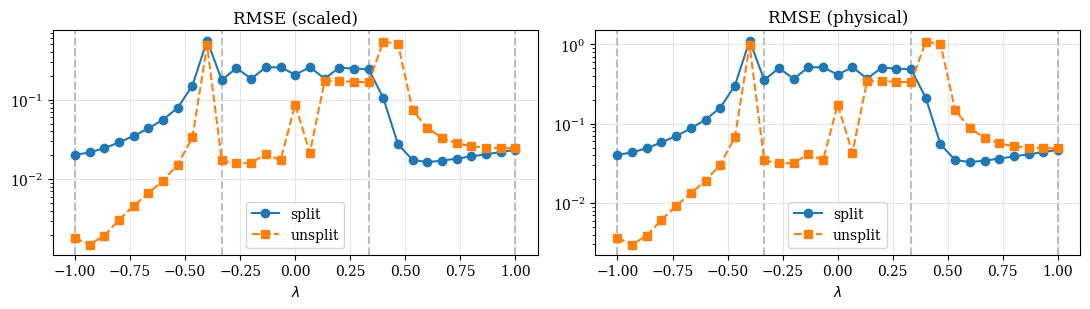

In [26]:
# Per-lambda RMSE comparison.
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
axs[0].plot(lams_data, rmse_scaled_split, 'o-', label='split', c='tab:blue')
axs[0].plot(lams_data, rmse_scaled_unsplit, 's--', label='unsplit', c='tab:orange')
axs[0].set_title('RMSE (scaled)'); axs[0].set_xlabel(r'$\lambda$'); axs[0].legend()
axs[1].plot(lams_data, rmse_phys_split, 'o-', label='split', c='tab:blue')
axs[1].plot(lams_data, rmse_phys_unsplit, 's--', label='unsplit', c='tab:orange')
axs[1].set_title('RMSE (physical)'); axs[1].set_xlabel(r'$\lambda$'); axs[1].legend()
for ax in axs:
    ax.set_yscale('log'); ax.grid(True, alpha=0.3)
    for lam_i in lams:
        ax.axvline(x=lam_i, color='gray', alpha=0.5, linestyle='--', zorder=0)
plt.tight_layout()
plt.show()

In [27]:
# Endpoint (t=100) absolute errors: |x_pred(t_end) - x_true(t_end)| for every (x0, lambda).
def endpoint_abs_err(pred_scaled, true_scaled, true_phys):
    pe_s = pred_scaled[:, :, -1, 0]            # [n_control, n_ic] scaled endpoints
    te_s = true_scaled[:, :, -1, 0]
    abs_s = np.abs(pe_s - te_s)
    pe_p = to_phys(pe_s)
    te_p = true_phys[:, :, -1, 0]
    abs_p = np.abs(pe_p - te_p)
    return abs_s, abs_p


abs_end_scaled_split, abs_end_phys_split = endpoint_abs_err(ys_split, Xs_scaled_grid, Xs_phys_grid)
abs_end_scaled_unsplit, abs_end_phys_unsplit = endpoint_abs_err(ys_unsplit, Xs_scaled_grid, Xs_phys_grid)

endpoint_errors = {
    'lambda': lams_data,
    'x0': xs_data,
    'abs_scaled_split': abs_end_scaled_split,
    'abs_phys_split': abs_end_phys_split,
    'abs_scaled_unsplit': abs_end_scaled_unsplit,
    'abs_phys_unsplit': abs_end_phys_unsplit,
}
1
print("Endpoint (t=100) absolute error over all (x0, lambda) cases:")
print(f"  split   : scaled  mean = {abs_end_scaled_split.mean():.4e}  max = {abs_end_scaled_split.max():.4e}  |  "
      f"physical  mean = {abs_end_phys_split.mean():.4e}  max = {abs_end_phys_split.max():.4e}")
print(f"  unsplit : scaled  mean = {abs_end_scaled_unsplit.mean():.4e}  max = {abs_end_scaled_unsplit.max():.4e}  |  "
      f"physical  mean = {abs_end_phys_unsplit.mean():.4e}  max = {abs_end_phys_unsplit.max():.4e}")

Endpoint (t=100) absolute error over all (x0, lambda) cases:
  split   : scaled  mean = 5.5008e-02  max = 1.0263e+00  |  physical  mean = 1.1002e-01  max = 2.0526e+00
  unsplit : scaled  mean = 5.1081e-02  max = 9.7548e-01  |  physical  mean = 1.0216e-01  max = 1.9510e+00


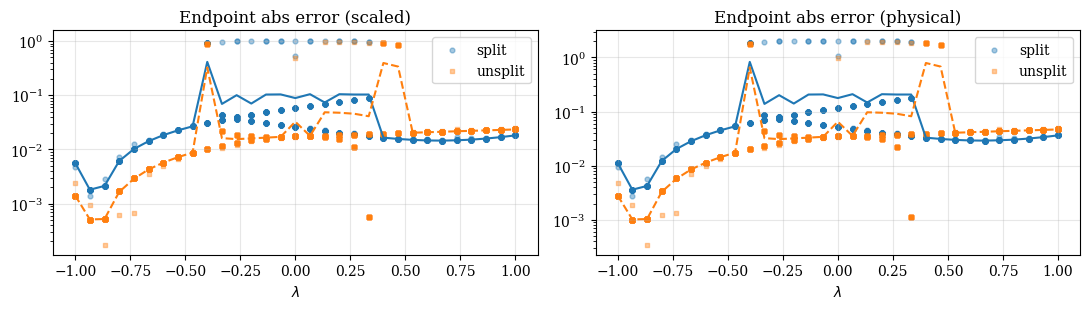

In [28]:
# Endpoint (t=100) absolute error across all control cases.
# Each control lambda contributes n_ic points (one per initial condition).
lam_rep = np.repeat(lams_data, n_ic)   # [n_control * n_ic]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, abs_split, abs_unsplit, title in (
    (axs[0], abs_end_scaled_split, abs_end_scaled_unsplit, 'Endpoint abs error (scaled)'),
    (axs[1], abs_end_phys_split, abs_end_phys_unsplit, 'Endpoint abs error (physical)'),
):
    ax.scatter(lam_rep, abs_split.ravel(), s=12, alpha=0.4, c='tab:blue', label='split')
    ax.scatter(lam_rep, abs_unsplit.ravel(), s=12, alpha=0.4, c='tab:orange', marker='s', label='unsplit')
    ax.plot(lams_data, abs_split.mean(axis=1), '-', c='tab:blue')      # per-lambda mean
    ax.plot(lams_data, abs_unsplit.mean(axis=1), '--', c='tab:orange')
    ax.set_title(title); ax.set_xlabel(r'$\lambda$')
    ax.set_yscale('log'); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

## 7. Jacobian eigenvalues at the trajectory steady states

Every `(x0, λ)` case is integrated to `t = 100` to settle; the final state is taken as
the simulated steady state `x*`. The 1×1 Jacobian eigenvalue of each model's RHS is
evaluated there (`eig < 0` ⇒ locally stable). MinMax scaling cancels in the chain rule,
so the scaled-coordinate eigenvalue equals the physical one. The analytic eigenvalue
`1 − 3x*²` is included for reference. Arrays are kept in-notebook (no files written).

In [29]:
from torch.autograd.functional import jacobian as torch_jacobian

model_split.eval()
model_unsplit.eval()


def split_eig(x_ss_scaled, lam):
    lam_t = torch.tensor([lam], dtype=torch.float32)
    x_t = torch.tensor([x_ss_scaled], dtype=torch.float32)
    J = torch_jacobian(lambda x: model_split(0.0, x.reshape(1, 1), lambda tt: lam_t).reshape(1), x_t)
    return np.linalg.eigvals(J.detach().numpy()).real[0]


def unsplit_eig(x_ss_scaled, lam):
    lam_t = torch.tensor([lam], dtype=torch.float32)
    x_t = torch.tensor([x_ss_scaled], dtype=torch.float32)
    J = torch_jacobian(lambda x: model_unsplit(x, lam_t), x_t)
    return np.linalg.eigvals(J.detach().numpy()).real[0]


# Settle each case to t=100, take the final state as the steady state.
ys_split_long = simulate_all(model_split, split=True, t_max_sim=100, n_colloc_sim=501)
ys_unsplit_long = simulate_all(model_unsplit, split=False, t_max_sim=100, n_colloc_sim=501)
x_ss_split = ys_split_long[:, :, -1, 0]      # [n_lam, n_traj] scaled
x_ss_unsplit = ys_unsplit_long[:, :, -1, 0]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

In [30]:
# Build eigenvalue tables.
# columns: [lambda, x0, x*_scaled, x*_physical, eig_model, is_stable, eig_true(1-3x*^2)]
split_traj_eig_rows = []
unsplit_traj_eig_rows = []
for li, lami in enumerate(tqdm(lams_data)):
    for xi in range(n_traj):
        x0v = xs_data[xi]

        xs_s = x_ss_split[li, xi]
        xs_p = scaler.inverse_transform(np.array([[xs_s]]))[0, 0]
        e_s = split_eig(xs_s, lami)
        split_traj_eig_rows.append([lami, x0v, xs_s, xs_p, e_s, float(e_s < 0), 1.0 - 3.0 * xs_p ** 2])

        xu_s = x_ss_unsplit[li, xi]
        xu_p = scaler.inverse_transform(np.array([[xu_s]]))[0, 0]
        e_u = unsplit_eig(xu_s, lami)
        unsplit_traj_eig_rows.append([lami, x0v, xu_s, xu_p, e_u, float(e_u < 0), 1.0 - 3.0 * xu_p ** 2])

cols = "[lambda, x0, x*_scaled, x*_physical, eig_model, is_stable, eig_true]"
split_traj_eig = np.array(split_traj_eig_rows)
unsplit_traj_eig = np.array(unsplit_traj_eig_rows)

print("split_traj_eig  ", split_traj_eig.shape, cols)
print("  stable:", int(split_traj_eig[:, 5].sum()), "/", len(split_traj_eig))
print("unsplit_traj_eig", unsplit_traj_eig.shape, cols)
print("  stable:", int(unsplit_traj_eig[:, 5].sum()), "/", len(unsplit_traj_eig))

  0%|          | 0/31 [00:00<?, ?it/s]

split_traj_eig   (124, 7) [lambda, x0, x*_scaled, x*_physical, eig_model, is_stable, eig_true]
  stable: 124 / 124
unsplit_traj_eig (124, 7) [lambda, x0, x*_scaled, x*_physical, eig_model, is_stable, eig_true]
  stable: 124 / 124


In [31]:
# Sign-agreement of model vs analytic stability at the settled states.
split_sign_match = np.mean((split_traj_eig[:, 4] < 0) == (split_traj_eig[:, 6] < 0))
unsplit_sign_match = np.mean((unsplit_traj_eig[:, 4] < 0) == (unsplit_traj_eig[:, 6] < 0))
print(f"stability sign agreement vs analytic (1-3x*^2):")
print(f"  split   : {split_sign_match:.3f}")
print(f"  unsplit : {unsplit_sign_match:.3f}")

stability sign agreement vs analytic (1-3x*^2):
  split   : 1.000
  unsplit : 0.968
